In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('dataset/population_by_country_2019_2020.csv')

In [9]:
print(data.head())

  Country (or dependency)  Population (2020)  Population (2019)  \
0                   China         1440297825         1445837915   
1                   India         1382345085         1395931716   
2           United States          331341050          333278784   
3               Indonesia          274021604          276919651   
4                Pakistan          221612785          225939807   

   Land Area (Km²)  Migrants (net)  Fert. Rate  Med. Age  
0          9388211       -348399.0         NaN      38.0  
1          2973190       -532687.0         NaN      28.0  
2          9147420        954806.0         NaN      38.0  
3          1811570        -98955.0         NaN      30.0  
4           770880       -233379.0         NaN      23.0  


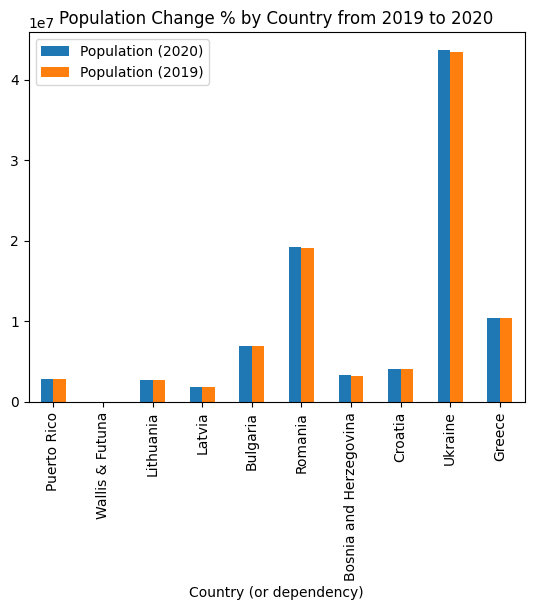

In [13]:
data['Net population change'] = data['Population (2020)'] - data['Population (2019)']
data['Population change %'] = (data['Net population change'] / data['Population (2019)']) * 100
data.sort_values(by='Population change %', ascending=False, inplace=True)
data.head(10).plot(kind='bar', x='Country (or dependency)', y=data.filter(regex=r"Population \(2019|2020\)").columns, title='Population Change % by Country from 2019 to 2020')
plt.show()

In [19]:
# Add Density column and insert "Low" 
data['Density (2020)'] = "Low"
data.loc[data["Population (2020)"] / data["Land Area (Km²)"] > 500, 'Density (2020)'] = "High"

In [21]:
# Pick every second country and save to new CSV file
data.iloc[::2, data.columns.get_loc('Country (or dependency)')].to_csv('dataset/population_output.csv', index=False)